   split  overloaded_node   count
0   test                0   35630
1   test                1    3840
2  train                0  114218
3  train                1  114218
4    val                0   28466
5    val                1    3016


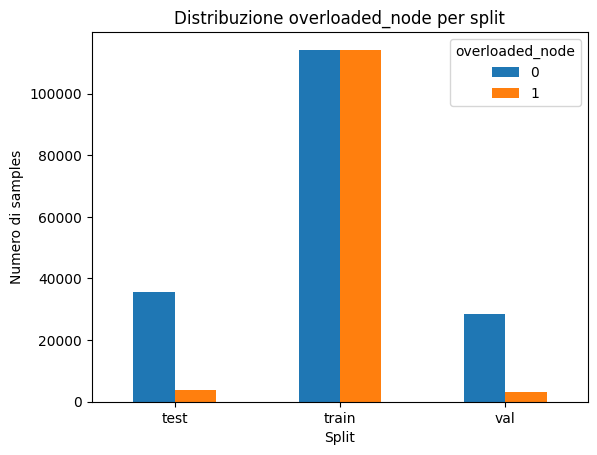

In [3]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

base_path = "/Users/kingsley/Documents/TESI/GITHUB_TESI/gl-forecasting-edge-performance/experiments/11n-8k/seed4850/0"

rows = []

for file in sorted(os.listdir(base_path)):
    if file.endswith("_data.json"):
        node_id = file.replace("_data.json", "")
        file_path = os.path.join(base_path, file)

        with open(file_path, "r") as f:
            data = json.load(f)

        for split in ["train", "val", "test"]:
            y_key = f"Y_{split}"

            if y_key in data:
                y = pd.DataFrame(data[y_key])
                overloaded = y.iloc[:, -1].astype(int)

                counts = overloaded.value_counts().reset_index()
                counts.columns = ["overloaded_node", "count"]
                counts["split"] = split
                counts["node"] = node_id

                rows.append(counts)

df_plot = pd.concat(rows, ignore_index=True)

summary = (
    df_plot
    .groupby(["split", "overloaded_node"])["count"]
    .sum()
    .reset_index()
)

print(summary)

summary.pivot(
    index="split",
    columns="overloaded_node",
    values="count"
).plot(kind="bar")

plt.title("Distribuzione overloaded_node per split")
plt.xlabel("Split")
plt.ylabel("Numero di samples")
plt.xticks(rotation=0)
plt.legend(title="overloaded_node")
plt.show()

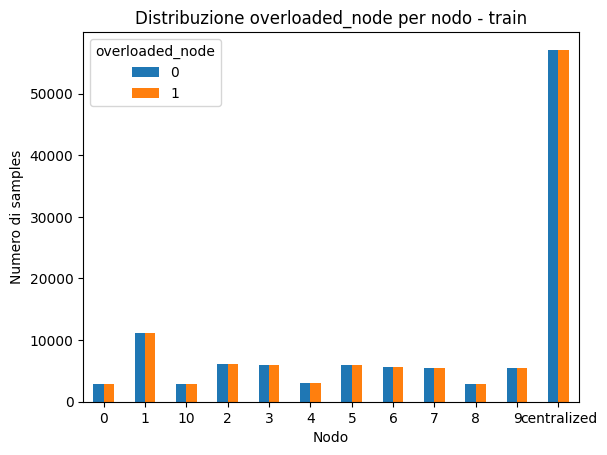

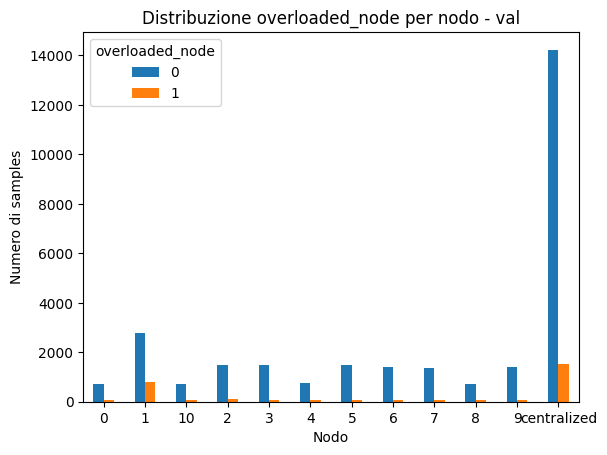

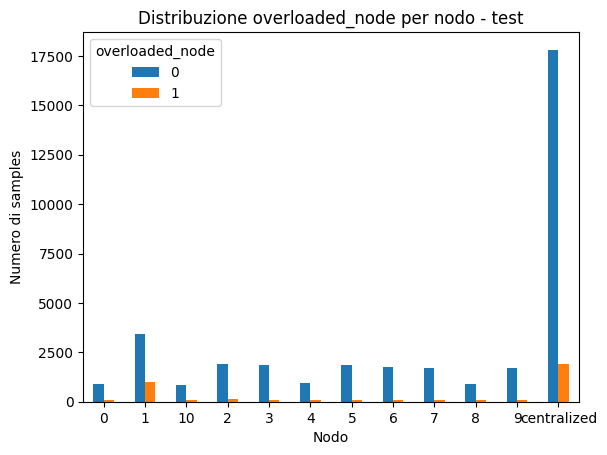

In [4]:
for split in ["train", "val", "test"]:
    df_split = df_plot[df_plot["split"] == split]

    pivot = df_split.pivot(
        index="node",
        columns="overloaded_node",
        values="count"
    ).fillna(0)

    pivot.plot(kind="bar")

    plt.title(f"Distribuzione overloaded_node per nodo - {split}")
    plt.xlabel("Nodo")
    plt.ylabel("Numero di samples")
    plt.xticks(rotation=0)
    plt.legend(title="overloaded_node")
    plt.show()